In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [1]:
import numpy as np
import pandas as pd

In [53]:
df_full_train = pd.read_csv("data/churn_data/churndata.csv")

In [54]:
df_full_train.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [55]:
df_full_train.columns = df_full_train.columns.str.lower().str.replace("_", " ")

In [56]:
df_full_train.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

In [57]:
object_col = df_full_train.dtypes[df_full_train.dtypes == "str"].index

In [58]:
for col in object_col:
    df_full_train[col] = df_full_train[col].str.lower().str.replace("_", " ")

In [59]:
df_full_train.head().T

,0,1,2,3,4
customerid,7590-vhveg,5575-gnvde,3668-qpybk,7795-cfocw,9237-hqitu
gender,female,male,male,male,female
seniorcitizen,0,0,0,0,0
partner,yes,no,no,no,no
dependents,no,no,no,no,no
tenure,1,34,2,45,2
phoneservice,no,yes,yes,no,yes
multiplelines,no phone service,no,no,no phone service,no
internetservice,dsl,dsl,dsl,dsl,fiber optic
onlinesecurity,no,yes,yes,yes,no


In [60]:
df_full_train["totalcharges"] = pd.to_numeric(df_full_train.totalcharges, errors="coerce")

In [61]:
df_full_train.dtypes

customerid              str
gender                  str
seniorcitizen         int64
partner                 str
dependents              str
tenure                int64
phoneservice            str
multiplelines           str
internetservice         str
onlinesecurity          str
onlinebackup            str
deviceprotection        str
techsupport             str
streamingtv             str
streamingmovies         str
contract                str
paperlessbilling        str
paymentmethod           str
monthlycharges      float64
totalcharges        float64
churn                   str
dtype: object

In [62]:
df_full_train.isnull().sum()

customerid           0
gender               0
seniorcitizen        0
partner              0
dependents           0
tenure               0
phoneservice         0
multiplelines        0
internetservice      0
onlinesecurity       0
onlinebackup         0
deviceprotection     0
techsupport          0
streamingtv          0
streamingmovies      0
contract             0
paperlessbilling     0
paymentmethod        0
monthlycharges       0
totalcharges        11
churn                0
dtype: int64

In [63]:
df_full_train.totalcharges = df_full_train.totalcharges.fillna(0)

In [64]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [66]:
df_full_train.churn = (df_full_train.churn == "yes").astype(int)

In [68]:
df_full_train.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train, X_test = train_test_split(df_full_train, test_size=0.6, random_state=1)
X_test, X_val = train_test_split(X_test, test_size=0.5, random_state=1)

In [71]:
X_train.shape, X_test.shape, X_val.shape

((2817, 21), (2113, 21), (2113, 21))

In [72]:
df_full_train.shape[0], (X_train.shape[0]+X_val.shape[0]+X_test.shape[0])

(7043, 7043)

In [73]:
y_train = X_train.churn.values
y_test = X_test.churn.values
y_val = X_val.churn.values

In [74]:
y_train.shape, y_test.shape, y_val.shape

((2817,), (2113,), (2113,))

In [75]:
del X_train["churn"]
del X_test["churn"]
del X_val["churn"]

In [76]:
female_churn = df_full_train[df_full_train.gender == "female"].churn.values
female_churn.mean()

np.float64(0.26920871559633025)

In [77]:
male_churn = df_full_train[df_full_train.gender == "male"].churn.values
male_churn.mean()

np.float64(0.2616033755274262)

In [78]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [79]:
global_churn = df_full_train.churn.values.mean()

In [80]:
df_full_train.churn.value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [81]:
global_churn

np.float64(0.2653698707936959)

In [82]:
partner_churn = df_full_train[df_full_train.partner == "yes"].churn.values.mean()

In [83]:
no_partner_churn = df_full_train[df_full_train.partner == "no"].churn.values.mean()

In [84]:
partner_churn - global_churn, no_partner_churn - global_churn

(np.float64(-0.06872084081133259), np.float64(0.06420991497944334))

In [85]:
## Risk Ratio

no_partner_churn/global_churn, partner_churn/global_churn

(np.float64(1.241963847619165), np.float64(0.7410375164075894))

In [86]:
from IPython.display import display

In [87]:
for c in categorical:
    df_group = df_full_train.groupby(c).churn.agg(["mean", "count"])
    df_group["diff"] = df_group["mean"] - global_churn
    df_group["risk"] = df_group["mean"]/global_churn
    display(df_group)

,mean,count,diff,risk
gender,,,,
female,0.269209,3488,0.003839,1.014466
male,0.261603,3555,-0.003766,0.985807


,mean,count,diff,risk
seniorcitizen,,,,
0,0.236062,5901,-0.029308,0.889557
1,0.416813,1142,0.151443,1.570686


,mean,count,diff,risk
partner,,,,
no,0.329580,3641,0.064210,1.241964
yes,0.196649,3402,-0.068721,0.741038


,mean,count,diff,risk
dependents,,,,
no,0.312791,4933,0.047422,1.178700
yes,0.154502,2110,-0.110868,0.582215


,mean,count,diff,risk
phoneservice,,,,
no,0.249267,682,-0.016103,0.939319
yes,0.267096,6361,0.001726,1.006506


,mean,count,diff,risk
multiplelines,,,,
no,0.250442,3390,-0.014927,0.943749
no phone service,0.249267,682,-0.016103,0.939319
yes,0.286099,2971,0.020729,1.078114


,mean,count,diff,risk
internetservice,,,,
dsl,0.189591,2421,-0.075779,0.714441
fiber optic,0.418928,3096,0.153558,1.578656
no,0.074050,1526,-0.191320,0.279044


,mean,count,diff,risk
onlinesecurity,,,,
no,0.417667,3498,0.152297,1.573906
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.146112,2019,-0.119258,0.550597


,mean,count,diff,risk
onlinebackup,,,,
no,0.399288,3088,0.133918,1.504645
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.215315,2429,-0.050055,0.811377


,mean,count,diff,risk
deviceprotection,,,,
no,0.391276,3095,0.125906,1.474456
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.225021,2422,-0.040349,0.847951


,mean,count,diff,risk
techsupport,,,,
no,0.416355,3473,0.150985,1.568960
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.151663,2044,-0.113706,0.571517


,mean,count,diff,risk
streamingtv,,,,
no,0.335231,2810,0.069861,1.263261
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.300702,2707,0.035332,1.133143


,mean,count,diff,risk
streamingmovies,,,,
no,0.336804,2785,0.071434,1.269188
no internet service,0.074050,1526,-0.191320,0.279044
yes,0.299414,2732,0.034044,1.128291


,mean,count,diff,risk
contract,,,,
month-to-month,0.427097,3875,0.161727,1.609440
one year,0.112695,1473,-0.152675,0.424672
two year,0.028319,1695,-0.237051,0.106714


,mean,count,diff,risk
paperlessbilling,,,,
no,0.163301,2872,-0.102069,0.615371
yes,0.335651,4171,0.070281,1.264842


,mean,count,diff,risk
paymentmethod,,,,
bank transfer (automatic),0.167098,1544,-0.098271,0.629681
credit card (automatic),0.152431,1522,-0.112939,0.574410
electronic check,0.452854,2365,0.187484,1.706502
mailed check,0.191067,1612,-0.074303,0.720003


In [88]:
df_group

,mean,count,diff,risk
paymentmethod,,,,
bank transfer (automatic),0.167098,1544,-0.098271,0.629681
credit card (automatic),0.152431,1522,-0.112939,0.574410
electronic check,0.452854,2365,0.187484,1.706502
mailed check,0.191067,1612,-0.074303,0.720003


In [89]:
df_full_train[numerical].corrwith(df_full_train.churn)

tenure           -0.352229
monthlycharges    0.193356
totalcharges     -0.198324
dtype: float64

In [90]:
from sklearn.metrics import mutual_info_score

In [91]:
mutual_info_score(df_full_train.tenure, df_full_train.churn)

0.07930906549876277

In [92]:
def mutual_score(x):
    return mutual_info_score(x,df_full_train.churn)

In [93]:
mi = df_full_train[categorical].apply(mutual_score)

In [94]:
mi.sort_values(ascending=False)

contract            0.098453
onlinesecurity      0.064677
techsupport         0.063021
internetservice     0.055574
onlinebackup        0.046792
paymentmethod       0.044519
deviceprotection    0.043917
streamingmovies     0.032001
streamingtv         0.031908
paperlessbilling    0.019194
dependents          0.014467
partner             0.011454
seniorcitizen       0.010577
multiplelines       0.000801
phoneservice        0.000072
gender              0.000037
dtype: float64

In [95]:
from sklearn.feature_extraction import DictVectorizer

In [96]:
dv = DictVectorizer(sparse=False)

In [97]:
dict_x = X_train[categorical + numerical].to_dict(orient="records")
dv.fit(dict_x)
x_train = dv.transform(dict_x)

In [98]:
x_train.shape

(2817, 45)

In [99]:
from sklearn.linear_model import LogisticRegression

In [100]:
model = LogisticRegression()

In [101]:
model.fit(x_train, y_train)

C:\Users\sonud\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [102]:
model.intercept_

array([-0.1429995])

In [103]:
model.coef_

array([[ 3.59465908e-01, -1.08341242e-01, -3.92041559e-01,
        -1.93265455e-04, -1.40723628e-01,  9.91908809e-02,
        -1.02855190e-01, -1.37252584e-01, -5.48715630e-02,
        -8.60453303e-02, -3.52184257e-01,  3.14122554e-01,
        -1.02855190e-01,  4.43142615e-03, -1.68892048e-01,
         6.43325966e-02, -3.63574418e-02,  1.31321122e-02,
        -1.02855190e-01, -5.11938157e-02,  2.68468678e-01,
        -1.02855190e-01, -3.06530381e-01, -2.71253623e-01,
         1.30336730e-01, -1.40431322e-01, -4.85571400e-04,
        -1.91091092e-01, -5.13880708e-02,  2.23163094e-01,
        -1.21600825e-01,  6.43325966e-02, -2.05249490e-01,
         3.15480841e-01, -9.27717520e-02, -1.02855190e-01,
         5.47100485e-02, -1.18505205e-01, -1.02855190e-01,
         8.04435014e-02,  2.16176674e-01, -1.02855190e-01,
        -2.54238378e-01, -8.40241394e-02,  5.37678366e-04]])

In [118]:
pred = model.predict(x_train)

In [119]:
pred

array([1, 0, 0, ..., 1, 0, 0], shape=(2817,))

In [120]:
(y_train == pred).mean()

np.float64(0.8111466098686546)

In [121]:
dict_val = X_val[categorical + numerical].to_dict(orient="records")
x_val = dv.transform(dict_val)

In [122]:
pred_val = model.predict(x_val)

In [123]:
(y_val == pred_val).mean()

np.float64(0.7979176526265973)

## Evaluation Of Model

In [124]:
## Accurarcy

(y_val ==pred_val).mean()

np.float64(0.7979176526265973)

In [125]:
from sklearn.metrics import accuracy_score

In [126]:
accuracy_score(y_val, pred_val)

0.7979176526265973

## Confusion Matrix

In [127]:
actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

In [128]:
predict_positive = (pred_val == 1)
predict_negative = (pred_val == 0)

In [129]:
tp = (actual_positive & predict_positive).sum()
tn = (actual_negative & predict_negative).sum()
fp = (predict_positive & actual_negative).sum()
fn = (actual_positive & predict_negative).sum()

In [130]:
tp, tn, fp, fn

(np.int64(339), np.int64(1347), np.int64(172), np.int64(255))

In [131]:
precision = tp/(tp+fp)
precision

np.float64(0.6634050880626223)

In [132]:
recall = tp/(tp+fn)
recall

np.float64(0.5707070707070707)

## ROC Curve

In [133]:
tpr = tp/(tp+fn)
tpr

np.float64(0.5707070707070707)

In [134]:
fpr = fp/(fp+tn)
fpr

np.float64(0.11323238973008558)

In [135]:
from sklearn.metrics import roc_curve

In [146]:
prob_val = model.predict_proba(x_val)[:, 1]
fpr, tpr , threshold = roc_curve(y_val, prob_val)

In [147]:
import matplotlib.pyplot as plt

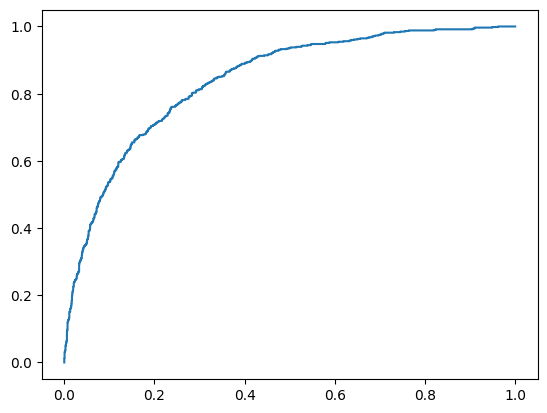

In [148]:
plt.plot(fpr,tpr)
plt.show()

In [149]:
pred_val

array([0, 0, 0, ..., 1, 0, 1], shape=(2113,))

In [150]:
val_pred = model.predict_proba(x_val)[:, 1]

In [151]:
val_pred

array([0.14567301, 0.34213362, 0.36090409, ..., 0.51479128, 0.43430402,
       0.63073917], shape=(2113,))

In [152]:
from sklearn.metrics import auc

In [153]:
auc(fpr, tpr)

0.8396040723229664

In [114]:
from sklearn.metrics import roc_auc_score

In [154]:
roc_auc_score(y_val, prob_val)

0.8396040723229664

In [156]:
from sklearn.model_selection import KFold

In [164]:
kfold = KFold(n_splits = 5, shuffle = True, random_state=1)

dict_vector = DictVectorizer()

score = []

for x_train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[x_train_idx]
    df_val = df_full_train.iloc[val_idx]

    dict_x = df_train[categorical + numerical].to_dict(orient="records")
    dict_val = df_val[categorical + numerical].to_dict(orient="records")

    dict_vector.fit(dict_x)
    x_train = dict_vector.transform(dict_x)
    x_val = dict_vector.transform(dict_val)

    y_train = df_train.churn.values
    y_val = df_val.churn.values

    model = LogisticRegression(C=5, max_iter=2000)
    model.fit(x_train, y_train)

    val_pred = model.predict_proba(x_val)[:, 1]

    score.append(roc_auc_score(y_val, val_pred))

C:\Users\sonud\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\sonud\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://s

In [165]:
s = np.array(score)
s.mean()

np.float64(0.8457230763491212)